# Introduction to Classification

**Classification** is a **supervised machine learning** technique where the goal is to predict a **category or class label** based on input features.

📌Output is discrete, not continuous.

---

## Basic Idea

- **Input (X)** → Features (independent variables)  
- **Output (Y)** → A category / class label (target variable)

The model learns from **labeled data** (data where the correct output is already known).

---

## Examples of Classification Problems

| Problem                     | Output Type               |
|-----------------------------|---------------------------|
| 📧 Spam Email Detection     | Spam / Not Spam           |
| 🏥 Disease Prediction       | Disease / No Disease      |
| ✍️ Handwritten Digit        | 0 – 9                     |
| 👤 Customer Type            | Gold / Silver / Bronze    |

---



# **Types of Classification**

## Binary Classification
- Two classes only  
- **Example:** Yes / No, 0 / 1  

## Multiclass Classification
- More than two classes  
- **Example:** Digits (0–9), Iris flower types 🌸  

## Multilabel Classification
- One data point can belong to multiple classes  
- **Example:** Movie genres 🎬 (Action + Comedy)

---

| Type                        | Description                    | Example              |
|-----------------------------|--------------------------------|----------------------|
| 🔹 Binary Classification    | 2 classes                      | Yes / No             |
| 🔢 Multiclass Classification| More than 2 classes            | Digit 0 – 9          |
| 🏷️ Multilabel Classification| Multiple labels at once        | Movie genres         |
| ⚖️ Imbalanced Classification| Unequal class distribution     | Fraud detection      |


# Common Classification Models

| Model                          | Used For                     |
|--------------------------------|------------------------------|
| 📈 Logistic Regression         | Simple & fast baseline       |
| 📍 K-Nearest Neighbors (KNN)   | Distance-based               |
| 🌳 Decision Tree               | Rule-based                   |
| 🌲 Random Forest               | Ensemble, high accuracy      |
| 📐 Support Vector Machine (SVM)| Margin-based                 |
| 📨 Naive Bayes                 | Text classification          |


# **1. Binary Classification**

**Model: Logistic Regression**

Logistic Regression is a supervised machine learning algorithm used for binary classification problems, where the output has two possible classes.

Instead of predicting continuous values (like Linear Regression), it predicts the **probability of a class using a sigmoid (logistic) function**.

# 🔍 How Logistic Regression Works

## Step 1: Linear Combination
It computes a linear combination of input features:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$


## Step 2: Sigmoid Function
This value is passed through a **Sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

➡️ The sigmoid converts any value into a **probability between 0 and 1**.


## Step 3: Decision Threshold
A threshold (usually **0.5**) is used:

- **Probability ≥ 0.5** → Class **1**  
- **Probability < 0.5** → Class **0**  


##  Why Logistic Regression is suitable here

✔ Binary classification problem  
✔ Medical prediction (probability-based decision)  
✔ Interpretable results  
✔ Works well with scaled numerical features  


**Breast Cancer Dataset (Binary Classification)**

The **Breast Cancer Wisconsin (Diagnostic) Dataset** is a medical dataset used to predict whether a breast tumor is:

- **Malignant (cancerous)** → `0`  
- **Benign (non-cancerous)** → `1`

👉 It is a **binary classification** problem because there are only **two possible classes**.



**📌 Dataset Characteristics**

| Property              | Value                         |
|-----------------------|-------------------------------|
| Total samples         | 569                           |
| Number of features    | 30                            |
| Target classes        | 2 (0, 1)                      |
| Type of features      | Continuous numerical values   |
| Missing values        | None                          |



🧬 What are the features (X)? **bold text**
Each **row** represents one patient, and each **column** represents measurements of a **cell nucleus** taken from a breast mass image.

**Examples of features:**
- Radius  
- Texture  
- Perimeter  
- Area  
- Smoothness  
- Compactness  
- Concavity  


**Target Variable (y)**

| Value | Meaning                      |
|------:|------------------------------|
| 0     | Malignant (Cancerous)        |
| 1     | Benign (Non-cancerous)       |

🎯 **Goal:**  
The model learns patterns from the features and predicts whether a tumor is **malignant or benign**.


**Import Libraries**

Key Components Used

- **`sklearn.datasets`** → Built-in datasets  
- **`train_test_split`** → Split data into training & testing  
- **`StandardScaler`** → Normalize data  
- **`LogisticRegression`** → Classification model  
- **`metrics`** → Evaluate model performance  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

 **Load Dataset**

 Data Representation
- **X** → Medical measurements (features)
- **y** → `0 = Malignant`, `1 = Benign` (labels)

In [2]:
data = load_breast_cancer()

X = data.data      # Features
y = data.target    # Labels

In [19]:
print("Feature names:\n", data.feature_names)
print("\nTarget names:\n", data.target_names)

Feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
 ['malignant' 'benign']


Convert to DataFrame for Easy Viewing

In [20]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Explore Target Distribution

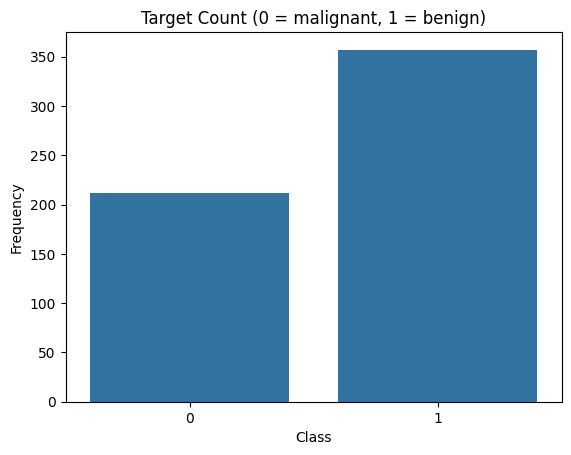

In [29]:
sns.countplot(x="target", data=df)
plt.title("Target Count (0 = malignant, 1 = benign)")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

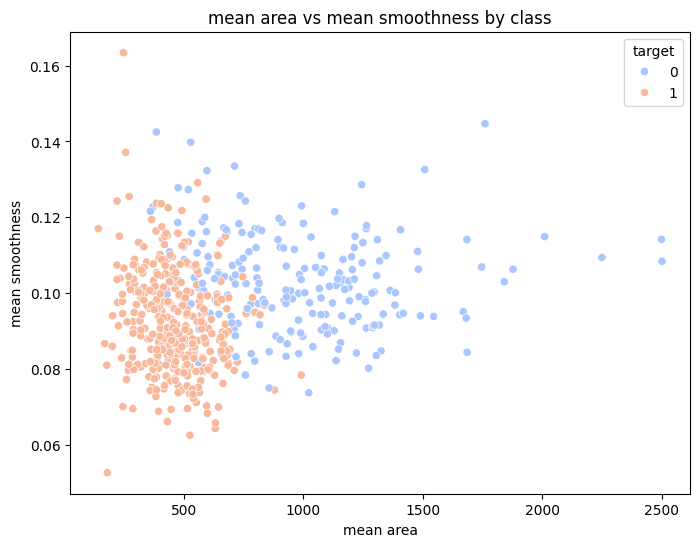

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["mean area"],
    y=df["mean smoothness"],
    hue=df["target"],
    palette="coolwarm"
)
plt.title("mean area vs mean smoothness by class")
plt.xlabel("mean area")
plt.ylabel("mean smoothness")
plt.show()

**Train-Test Split**

Data Split
- **80% data** → Training  
- **20% data** → Testing  

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

 **Feature Scaling**

Feature scaling brings all input features to a **similar scale**, so that no feature dominates others due to large values.

 Example Problem Without Scaling

- **Feature 1:** Age → values around **20–60**  
- **Feature 2:** Salary → values around **30,000–1,00,000**

👉 ML models may give more importance to **Salary** just because its values are larger.


**What is StandardScaler?**

**StandardScaler** standardizes features using **Z-score normalization**:

$$
X_{scaled} = \frac{X - \mu}{\sigma}
$$

Where:
- **μ (mu)** = Mean of the feature  
- **σ (sigma)** = Standard deviation of the feature  


After Scaling
- **Mean = 0**  
- **Standard Deviation = 1**  

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

** Train Logistic Regression**


*   Learns the relationship between features and class labels



In [30]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Prediction**

In [8]:
y_pred = model.predict(X_test)

**Evaluation**

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


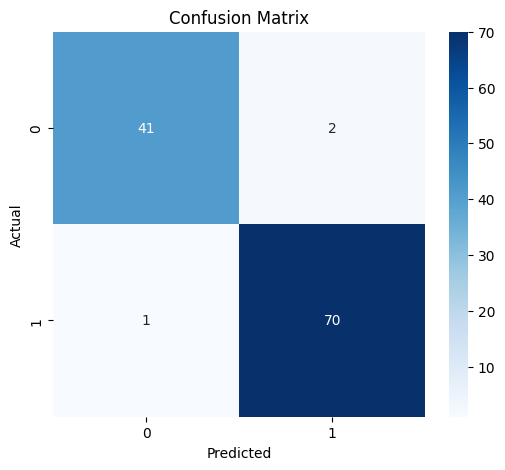

In [25]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# **2. k-Nearest Neighbors (k-NN)**

**k-NN** is a **supervised**, **distance-based** learning algorithm.


A data point is classified based on the **majority class of its k nearest neighbors**.

-  No explicit training phase  
- Stores all training data  
- Predictions are made using distance calculations  


Working:

1. Choose a value for **k** (e.g., k = 3 or 5)  
2. Calculate distance between the new data point and all training points  
Common distance: **Euclidean distance**  
3. Select the **k closest neighbors**  
4. Perform **majority voting** among the neighbors  
5. Assign the class with the **highest votes**


Distance Formula (Euclidean)

$$
d = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
$$

### Where:
- **xᵢ** → Feature value of test point  
- **yᵢ** → Feature value of training point  


**Iris Dataset (Multiclass Classification)**

📌 Dataset Link https://archive.ics.uci.edu/ml/datasets/iris

The **Iris Dataset** is a classic **multiclass classification** dataset used to classify iris flowers into **three species** based on flower measurements.

It is widely used for learning and teaching classification algorithms 📘.


📌 Dataset Characteristics

| Property        | Value                    |
|-----------------|--------------------------|
| Total samples   | 150                      |
| Features        | 4                        |
| Classes         | 3                        |
| Type            | Multiclass classification|

📌 Features (X)

The dataset contains **four numerical features**:

- 🌿 Sepal length (cm)  
- 🌿 Sepal width (cm)  
- 🌸 Petal length (cm)  
- 🌸 Petal width (cm)  

These measurements describe the **physical structure of the flower**.

Target Classes (y)

| Label | Class Name         |
|------:|--------------------|
| 0     | Iris Setosa        |
| 1     | Iris Versicolor    |
| 2     | Iris Virginica     |


**Import Required Libraries**

- **`sklearn.datasets`** → Loads built-in datasets  
- **`KNeighborsClassifier`** → KNN algorithm  
- **`metrics`** → Evaluate model performance  
- **`seaborn / matplotlib`** → Visualizations  

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load the Iris Dataset**

In [32]:
iris = load_iris()
X = iris.data
y = iris.target

**Dataset Information**

In [33]:
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Dataset shape:", X.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Dataset shape: (150, 4)


**Convert to DataFrame**

*   Makes plotting and exploration easier



In [34]:
df = pd.DataFrame(X, columns=iris.feature_names)
df["species"] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Visualize Class Distribution**

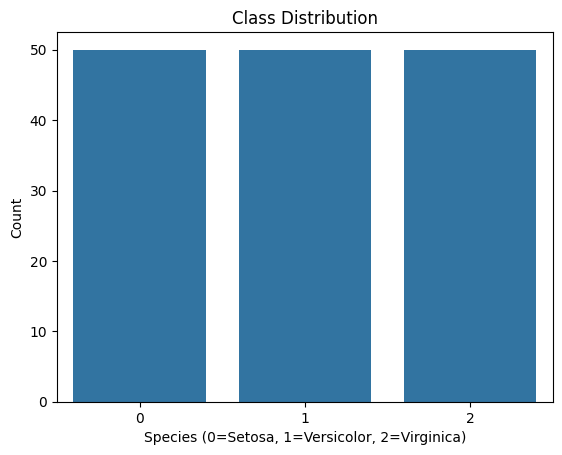

In [35]:
sns.countplot(x="species", data=df)
plt.title("Class Distribution")
plt.xlabel("Species (0=Setosa, 1=Versicolor, 2=Virginica)")
plt.ylabel("Count")
plt.show()



*   All classes are perfectly balanced

*   Good dataset for classification





**Feature Visualization**

Scatter Plot (Petal Length vs Petal Width)

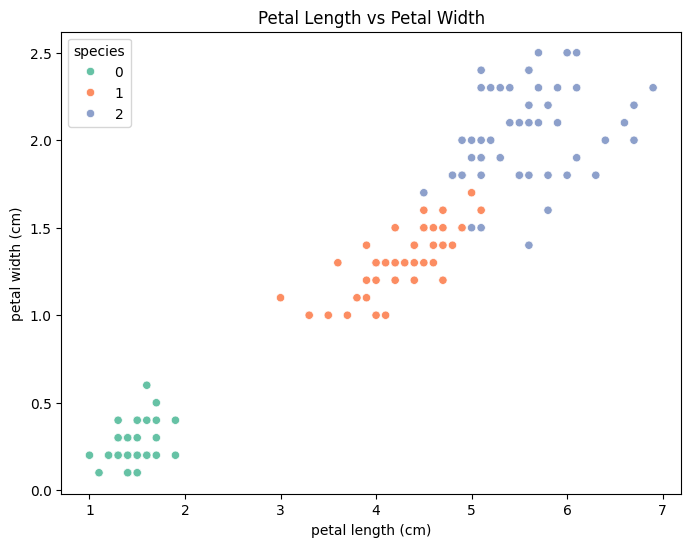

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["petal length (cm)"],
    y=df["petal width (cm)"],
    hue=df["species"],
    palette="Set2"
)
plt.title("Petal Length vs Petal Width")
plt.show()

Scatter Plot (Sepal Length vs Sepal Width)

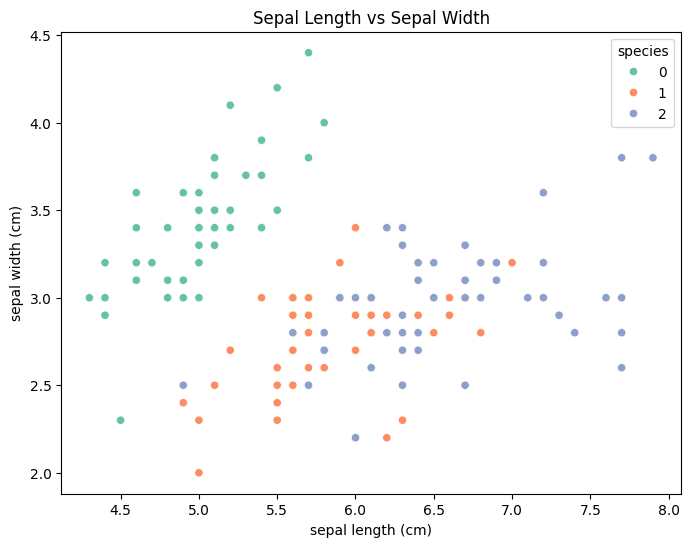

In [37]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["sepal length (cm)"],
    y=df["sepal width (cm)"],
    hue=df["species"],
    palette="Set2"
)
plt.title("Sepal Length vs Sepal Width")
plt.show()

**Train–Test Split**

* 75% training data

* 25% testing data

* random_state=0 → reproducible results

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

**Train KNN Classifier**

- KNN stores all **training points**  
- For a new data point:
  - Finds **5 nearest neighbors**  
  - Assigns the **most common class** among them  

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

**Prediction**

In [40]:
y_pred = knn.predict(X_test)

**Model Evaluation**

Accuracy

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


Confusion Matrix

* Diagonal values → correct predictions

* Off-diagonal → misclassifications

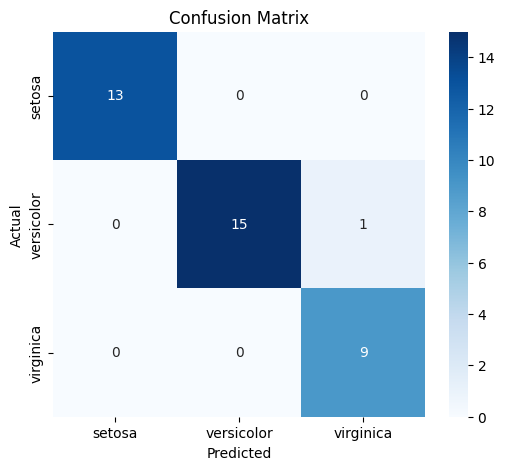

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Classification Report**

* Precision

* Recall

* F1-score for each class

In [43]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



# **3. Decision Tree**


A **Decision Tree** is a **supervised machine learning** algorithm used for **classification and regression**.  
It works by splitting data into **branches** based on feature values until a final decision (class) is reached.

It looks like an **upside-down tree**:

- **Root node** → First decision  
- **Internal nodes** → Conditions  
- **Leaf nodes** → Final class label  

**How Decision Tree Works**

1. Select the **best feature** to split the data  
2. Split the dataset based on a condition (e.g., `Age < 30`)  
3. Repeat splitting for each branch  
4. Stop when:
- Data is **pure**, or  
- **Maximum depth** is reached  

5. Assign **class labels** at leaf nodes  

**Important Concepts Used**

- **Gini Index** → Measures impurity  
- **Entropy & Information Gain** → Measure information reduction  
- **Max Depth** → Controls tree size (prevents overfitting)  


**Titanic Dataset (Binary Classification)**

The **Titanic Dataset** is a real-world **binary classification** dataset used to predict whether a passenger **survived or did not survive** the Titanic disaster.

It is widely used to demonstrate **classification**, **data preprocessing**, and **feature engineering**.


**📌 Dataset Source**
🔗 https://www.kaggle.com/datasets/yasserh/titanic-dataset



**📌 Dataset Characteristics**

| Property          | Value                          |
|-------------------|--------------------------------|
| Problem Type      | Binary Classification          |
| Target Variable   | Survived                       |
| Classes           | 0 = No, 1 = Yes                |
| Data Type         | Mixed (numerical + categorical)|



 **Common Features Used (X)**

| Feature | Description                       |
|--------|-----------------------------------|
| Pclass | Passenger class (1st, 2nd, 3rd)   |
| Sex    | Male / Female                     |
| Age    | Passenger age                     |
| Fare   | Ticket price                      |


**Target Variable (y)**

| Value | Meaning            |
|------:|--------------------|
| 0     | Did not survive    |
| 1     | Survived           |


**Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Load the Dataset**



In [2]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Cleaning & Preprocessing**

In [3]:
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].copy()

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [4]:
df.head()

,Pclass,Sex,Age,Fare,Survived
0,3,0,22.0,7.2500,0
1,1,1,38.0,71.2833,1
2,3,1,26.0,7.9250,1
3,1,1,35.0,53.1000,1
4,3,0,35.0,8.0500,0


**Visualize Survival Distribution**



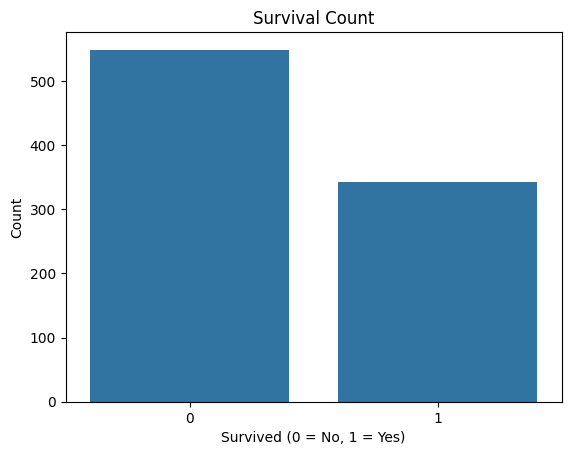

In [62]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

**Feature-wise Visualization**

Survival by Passenger Class

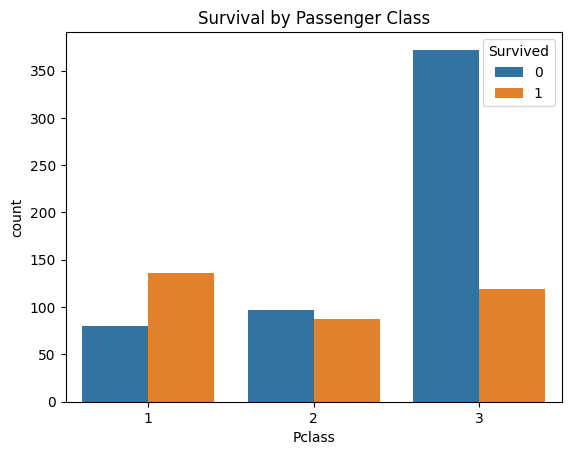

In [63]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

**Split Data into Features & Target**

In [5]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Train Decision Tree Classifier**

In [6]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Prediction & Accuracy**

In [7]:
y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8044692737430168


**Confusion Matrix**

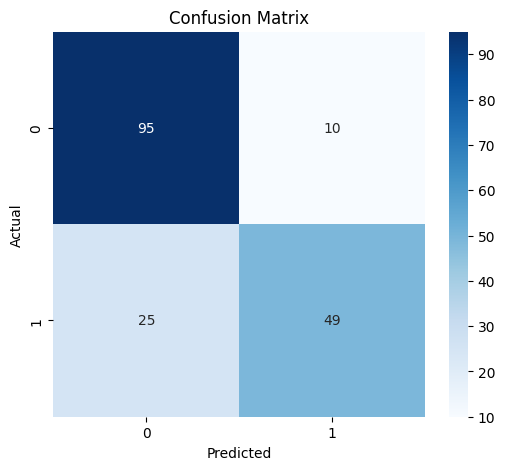

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Classification Report**

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



**Visualize the Decision Tree**

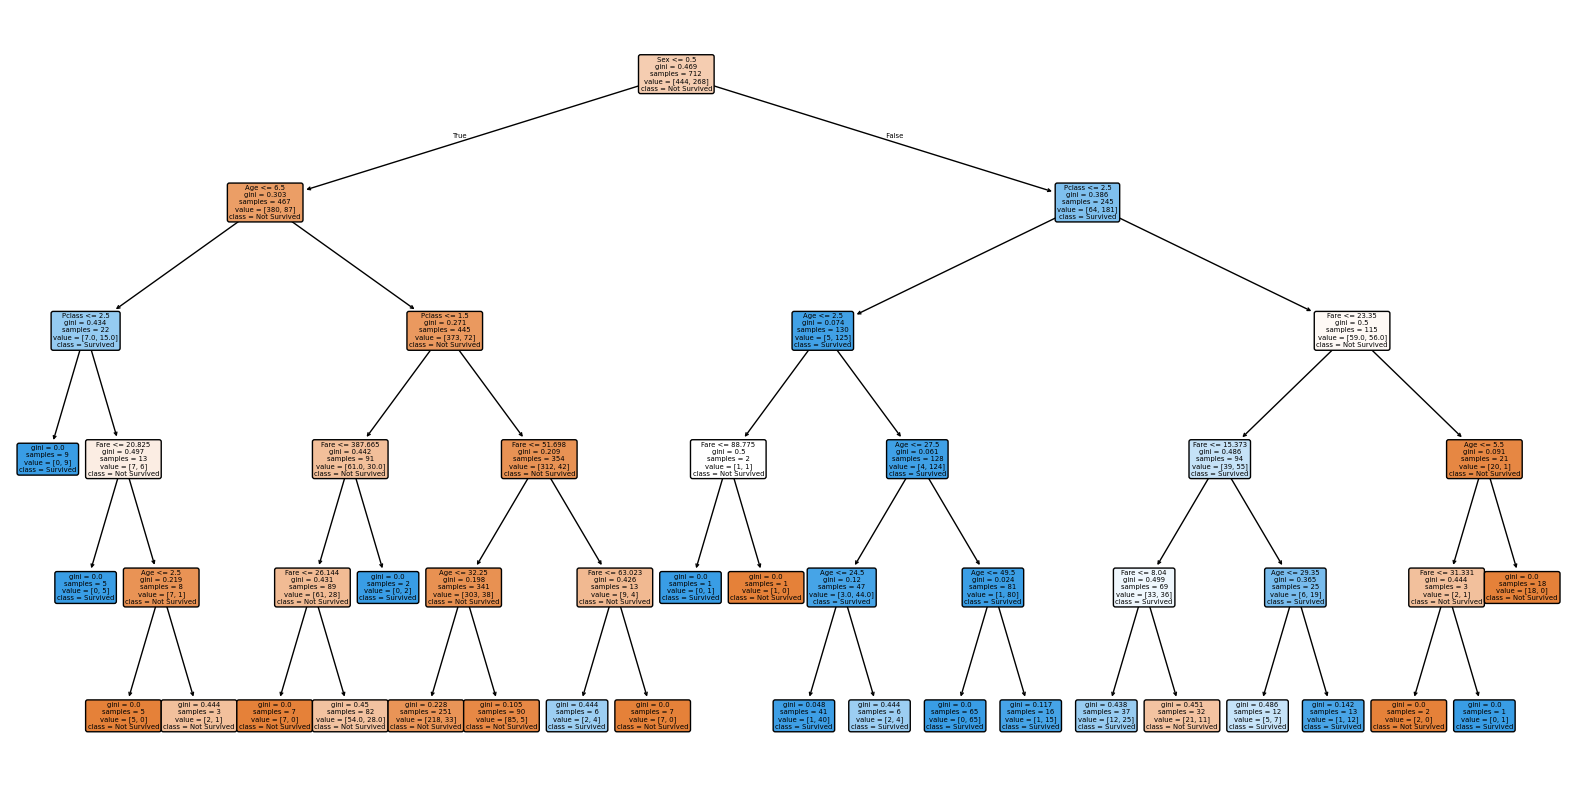

In [10]:
plt.figure(figsize=(20,10))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True
)
plt.show()

# **4. Random Forest Classification**


**Random Forest** is a **supervised ensemble machine learning** algorithm used for **classification and regression**.

It works by building **multiple decision trees** and combining their results to produce a **more accurate and stable prediction**.


- **Random** → Random selection of data and features 🎲  
- **Forest** → Collection of many decision trees 🌳  

**How Random Forest Works**
1. Randomly select samples from the dataset (**bootstrap sampling**)  
2. Build a **decision tree** for each sample  
3. At each split, select a **random subset of features**  
4. Each tree gives a **prediction**  
5. Final output is decided by **majority voting** (classification)


Predict whether a passenger survived using a Random Forest, which is an ensemble of multiple decision trees

**Import Required Libraries**

In [11]:
from sklearn.ensemble import RandomForestClassifier

**Train Random Forest Classifier**


In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)



- **n_estimators = 100** → Builds **100 decision trees**

**Each Tree:**
- Sees **random samples** from the dataset  
- Uses **random subsets of features**

**Final Prediction**
- Each tree gives a prediction  
- **Majority vote** decides the final class


**Prediction & Accuracy**

In [13]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8100558659217877


**Confusion Matrix**

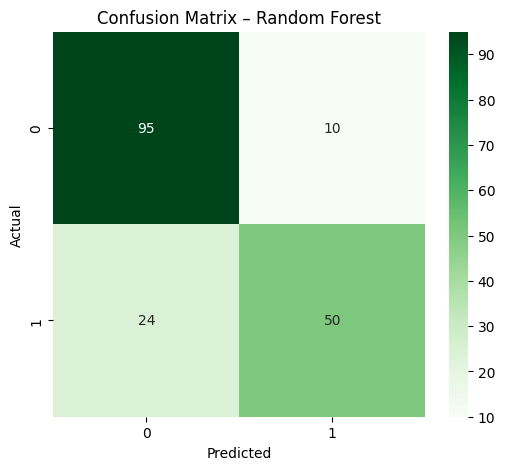

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")
plt.show()

**Classification Report**

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       105
           1       0.83      0.68      0.75        74

    accuracy                           0.81       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



**Feature Importance**

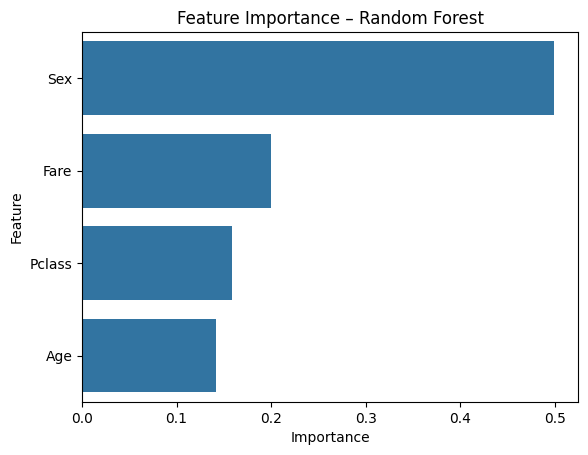

In [16]:
importances = rf.feature_importances_

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Feature Importance – Random Forest")
plt.show()